Reads the ablation results and visualizes them

In [9]:
%matplotlib inline
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tabulate import tabulate

# ── paths ──────────────────────────────────────────────────────────────────────
REMOTE_PATH = Path("/home/adrian/.mnt/horeka/experiments/survival/observation_spaces/ablation_rl_only/")
LOCAL_PATH  = Path("/home/adrian/Dev/NRI-for-explainable-RL-in-Power-Grids/experiments/survival/observation_spaces/ablation_rl_only/")

PATH = REMOTE_PATH if REMOTE_PATH.exists() else LOCAL_PATH
print(f"Using: {PATH}")

FIGURES = LOCAL_PATH.parent
FIGURES.mkdir(parents=True, exist_ok=True)

# ── plot style ─────────────────────────────────────────────────────────────────
sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 11})

Using: /home/adrian/.mnt/horeka/experiments/survival/observation_spaces/ablation_rl_only


In [10]:
def parse_method_seed(dir_name: str) -> tuple[str, int]:
    """Parse 'MethodName_SeedNum' directory name into (method_name, seed).

    Args:
        dir_name: directory name in format 'Method_Seed' (e.g. 'Default_0')
    Returns:
        (method, seed) tuple
    """
    parts = dir_name.rsplit("_", 1)
    if len(parts) == 2 and parts[1].isdigit():
        return parts[0], int(parts[1])
    return dir_name, 0


def load_episodes(method_seed_dir: Path) -> list[dict]:
    """Load all episode_meta.json files from a method-seed evaluation directory.

    Args:
        method_seed_dir: directory containing numbered episode sub-folders
    Returns:
        list of dicts with keys: nb_timestep_played, max_timestep, survival_pct
    """
    episodes = []
    for episode_dir in sorted(method_seed_dir.iterdir()):
        meta_path = episode_dir / "episode_meta.json"
        if not meta_path.exists():
            continue
        with meta_path.open() as f:
            meta = json.load(f)
        nb_steps  = meta["nb_timestep_played"]
        max_steps = int(meta.get("chronics_max_timestep", 8064))
        episodes.append({
            "nb_timestep_played": nb_steps,
            "max_timestep":       max_steps,
            "survival_pct":       nb_steps / max_steps * 100,
        })
    return episodes


# ── discover all method-seed directories ──────────────────────────────────────
# data: method -> seed -> list of episode dicts
data: dict[str, dict[int, list[dict]]] = {}

for d in sorted(PATH.iterdir()):
    if not d.is_dir():
        continue
    method, seed = parse_method_seed(d.name)
    episodes = load_episodes(d)
    if not episodes:
        continue
    data.setdefault(method, {})[seed] = episodes
    print(f"  {d.name}: {len(episodes)} episodes")

METHODS = sorted(data.keys())
print(f"\nMethods: {METHODS}")

  Default_ablated: 42 episodes
  Default_baseline: 42 episodes
  Elements + LODF_ablated: 42 episodes
  Elements + LODF_baseline: 42 episodes
  Elements_ablated: 42 episodes
  Elements_baseline: 42 episodes
  Heterogeneous_ablated: 42 episodes
  Heterogeneous_baseline: 42 episodes
  LODF_ablated: 42 episodes
  LODF_baseline: 42 episodes
  PTDF_ablated: 42 episodes
  PTDF_baseline: 42 episodes
  Substation + PTDF_ablated: 42 episodes
  Substation + PTDF_baseline: 42 episodes
  Substation + Zbus_ablated: 42 episodes
  Substation + Zbus_baseline: 42 episodes
  Substation_ablated: 42 episodes
  Substation_baseline: 42 episodes
  Zbus_ablated: 42 episodes
  Zbus_baseline: 42 episodes

Methods: ['Default_ablated', 'Default_baseline', 'Elements + LODF_ablated', 'Elements + LODF_baseline', 'Elements_ablated', 'Elements_baseline', 'Heterogeneous_ablated', 'Heterogeneous_baseline', 'LODF_ablated', 'LODF_baseline', 'PTDF_ablated', 'PTDF_baseline', 'Substation + PTDF_ablated', 'Substation + PTDF_b

In [11]:
# ── build flat DataFrame: one row per episode ─────────────────────────────────
records = []
for method, seeds in data.items():
    for seed, episodes in seeds.items():
        for ep in episodes:
            records.append({
                "Method":     method,
                "Seed":       seed,
                "Steps":      ep["nb_timestep_played"],
                "Survival %": ep["survival_pct"],
            })

df = pd.DataFrame(records)
df["Seed Label"] = "Seed " + df["Seed"].astype(str)

MAX_STEPS = int(df["Steps"].max())
print(f"Max episode length: {MAX_STEPS} steps\n")
print(df.groupby("Method")["Survival %"].describe().round(1))

Max episode length: 8064 steps

                            count  mean   std   min    25%    50%    75%  \
Method                                                                     
Default_ablated              42.0  93.5  17.3  35.0  100.0  100.0  100.0   
Default_baseline             42.0  97.5  11.6  35.0  100.0  100.0  100.0   
Elements + LODF_ablated      42.0  66.6  33.8   9.8   37.3   62.6  100.0   
Elements + LODF_baseline     42.0  95.2  15.0  35.0  100.0  100.0  100.0   
Elements_ablated             42.0  58.6  35.9   5.8   21.2   64.7  100.0   
Elements_baseline            42.0  87.1  26.0  13.2   89.3  100.0  100.0   
Heterogeneous_ablated        42.0  97.5  11.6  35.0  100.0  100.0  100.0   
Heterogeneous_baseline       42.0  97.5  11.6  35.0  100.0  100.0  100.0   
LODF_ablated                 42.0  97.5  11.6  35.0  100.0  100.0  100.0   
LODF_baseline                42.0  97.5  11.6  35.0  100.0  100.0  100.0   
PTDF_ablated                 42.0  92.3  23.8   6.4  100

## Summary Table

Mean / median survival % per method, sorted by mean survival (best → worst).
"100 % episodes" = fraction of episodes where the agent survived the full chronic.

In [12]:
rows = []
for method in METHODS:
    s = df[df["Method"] == method]["Survival %"]
    rows.append([
        method,
        float(s.mean()),           # sort key
        f"{s.mean():.1f}",
        f"{s.median():.1f}",
        f"{s.std():.1f}",
        f"{(s >= 100).mean() * 100:.1f}",
        len(s),
    ])

rows.sort(key=lambda r: r[1], reverse=True)
rows = [[r[0], r[2], r[3], r[4], r[5], r[6]] for r in rows]   # drop sort key

headers = ["Method", "Mean Surv. %", "Median Surv. %", "Std", "100% Episodes %", "N Episodes"]
print(tabulate(rows, headers=headers, tablefmt="github"))

| Method                     |   Mean Surv. % |   Median Surv. % |   Std |   100% Episodes % |   N Episodes |
|----------------------------|----------------|------------------|-------|-------------------|--------------|
| Default_baseline           |           97.5 |            100   |  11.6 |              95.2 |           42 |
| Heterogeneous_ablated      |           97.5 |            100   |  11.6 |              95.2 |           42 |
| Heterogeneous_baseline     |           97.5 |            100   |  11.6 |              95.2 |           42 |
| LODF_ablated               |           97.5 |            100   |  11.6 |              95.2 |           42 |
| LODF_baseline              |           97.5 |            100   |  11.6 |              95.2 |           42 |
| Substation + PTDF_baseline |           97.4 |            100   |  11.6 |              92.9 |           42 |
| Zbus_baseline              |           95.8 |            100   |  14   |              88.1 |           42 |
| PTDF_bas

## Survival Distribution — All Seeds Aggregated

Boxplot of survival % per method, with individual episode outcomes as overlaid dots.

/tmp/ipykernel_3756504/4163675713.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


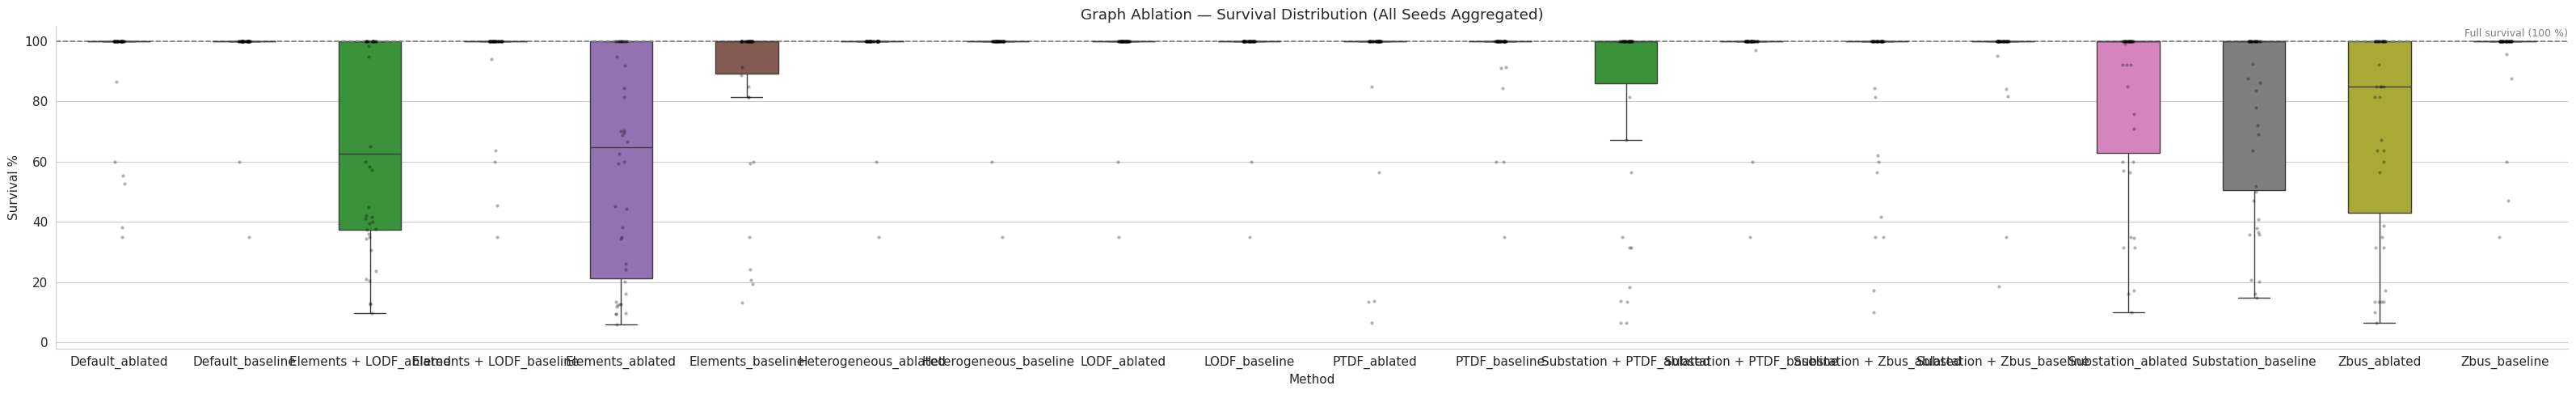

In [13]:
palette = dict(zip(METHODS, sns.color_palette("tab10", len(METHODS))))

fig, ax = plt.subplots(figsize=(max(5, len(METHODS) * 1.6), 5))
sns.boxplot(
    data=df, x="Method", y="Survival %",
    palette=palette, order=METHODS, width=0.5, fliersize=0, ax=ax,
)
sns.stripplot(
    data=df, x="Method", y="Survival %",
    color="black", alpha=0.3, size=3.0, jitter=0.05, order=METHODS, ax=ax,
)
ax.axhline(100, ls="--", color="gray", lw=1.2)
ax.text(len(METHODS) - 0.5, 101.5, "Full survival (100 %)",
        color="gray", fontsize=9, ha="right")
ax.set_ylim(-2, 105)
ax.set_title("Graph Ablation — Survival Distribution (All Seeds Aggregated)")
ax.set_ylabel("Survival %")
sns.despine(ax=ax)
plt.tight_layout()
fig.savefig(FIGURES / "ablation_graph_boxplot_aggregated.png", dpi=150)
plt.show()

## Survival Distribution — Per Seed

Same data broken out by seed to check consistency across runs.

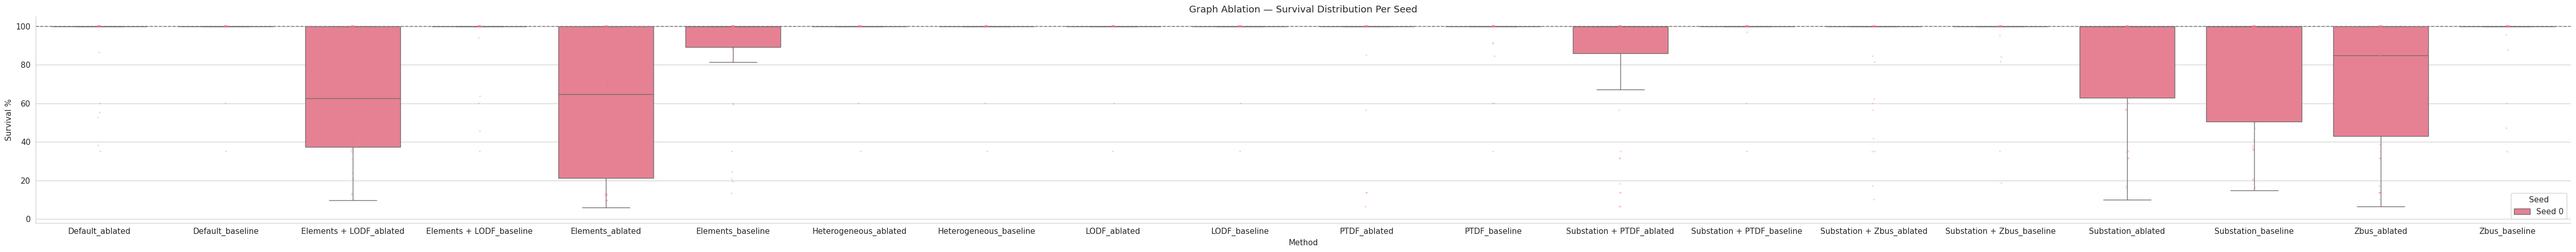

In [14]:
all_seeds   = sorted(df["Seed"].unique())
n_seeds     = len(all_seeds)
seed_labels = {s: f"Seed {s}" for s in all_seeds}
seed_palette = dict(zip(
    [seed_labels[s] for s in all_seeds],
    sns.color_palette("husl", n_seeds),
))

fig, ax = plt.subplots(figsize=(max(8, len(METHODS) * 2.5), 5))
sns.boxplot(
    data=df, x="Method", y="Survival %", hue="Seed Label",
    palette=seed_palette, order=METHODS, width=0.75, fliersize=0, ax=ax,
)
sns.stripplot(
    data=df, x="Method", y="Survival %", hue="Seed Label",
    palette=seed_palette, order=METHODS,
    dodge=True, alpha=0.3, size=2.5, jitter=0.01, legend=False, ax=ax,
)
ax.axhline(100, ls="--", color="gray", lw=1.2)
ax.set_ylim(-2, 105)
ax.set_title("Graph Ablation — Survival Distribution Per Seed")
ax.set_ylabel("Survival %")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:n_seeds], labels[:n_seeds], title="Seed",
          loc="lower right", framealpha=0.85)
sns.despine(ax=ax)
plt.tight_layout()
fig.savefig(FIGURES / "ablation_graph_boxplot_per_seed.png", dpi=150)
plt.show()